# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [2]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [ ]:
# pd.read_csv("../../../datasets/Salary Data.csv").head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv")

### Step 2.a Assign variables `X` to the features and `y` to the target

In [4]:
X = df[["Experience Years"]]
y = df[["Salary"]]


### Step 2.b print the type of each

In [5]:
print(X.dtypes)
print(y.dtypes)

Experience Years    float64
dtype: object
Salary    int64
dtype: object


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [6]:
# the target (Salary) is a numeric variable, and the feature (Experience Years) is also a numeric variable
# This means that we can use linear regression to model the relationship between the two variables

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [7]:
print("Data matrix (X):", X.shape)
print("Target (y):", y.shape)

Data matrix (X): (40, 1)
Target (y): (40, 1)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [8]:
print("X summary:")
print(X.agg(["min", "max", "median", "mean", "std"]))

print("\ny summary:")
print(y.agg(["min", "max", "median", "mean", "std"]))


X summary:
        Experience Years
min             1.100000
max            10.500000
median          4.600000
mean            5.152500
std             2.663715

y summary:
               Salary
min      37731.000000
max     122391.000000
median   64472.500000
mean     74743.625000
std      25947.122885


### Step 5. Plot the feature vs the target

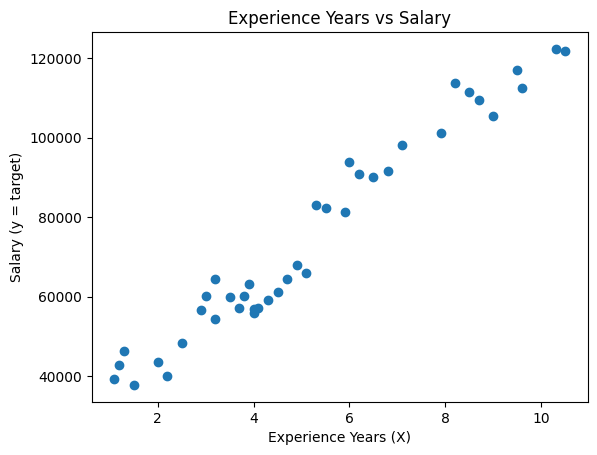

In [9]:
import matplotlib.pyplot as plt

plt.scatter(X["Experience Years"], y)
plt.xlabel("Experience Years (X)")
plt.ylabel("Salary (y = target)")
plt.title("Experience Years vs Salary")
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [ ]:
# There is a strong positive correlation between experience years and salary,
# Which mean its an increasing relationship, as the experience years increases, the salary also tend to increase.
# So, employees who have more experience years their salary tend to increase.

### Step 7. Initialize a regression model

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Step 9.a Train the model on the training set

In [12]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [13]:
print("Slope:", model.coef_[0])
print("y-intercept:", model.intercept_)

Slope: [9408.03127251]
y-intercept: [26716.25017615]


### Step 9.c how much salary does a person get with 2 years of experience?

In [ ]:
# since the slope = 9408 we can say that we get 9408 SAR for each year of experience

### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [21]:
halfY = int(model.coef_[0]/2)
print("Salary increase for 6 months of experience:", halfY)


Salary increase for 6 months of experience: 4704


/var/folders/tp/yr6_9jgn68510mgmglpq2m2r0000gn/T/ipykernel_10932/3326792328.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  halfY = int(model.coef_[0]/2)


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [24]:
# he will get the intercept
print("if a person have no experience he will get:", int(model.intercept_), "SAR salary")

if a person have no experience he will get: 26716 SAR salary


/var/folders/tp/yr6_9jgn68510mgmglpq2m2r0000gn/T/ipykernel_10932/1180313213.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("if a person have no experience he will get:", int(model.intercept_), "SAR salary")


### Step 10. Evaluate the model on the test set

In [ ]:
score = model.score(X_test, y_test)
print("R^2 score:", score)
# The R^2 score is a measure of how well the model explains the variance in the target variable (y) 
# Based on the features (X). A score of 0.90 indicates that the model explains 90% of the variance in the target variable. 
# Which suggests a very good fit to the data.

R^2 score: 0.9068577573647874


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [31]:

sample_X = X_test.head(3)
sample_y = y_test.head(3)

predictions = model.predict(sample_X)

results = sample_X.copy()
results["True_Marks"] = sample_y.values
results["Predicted_Marks"] = predictions
results["Match"] = results["True_Marks"] == results["Predicted_Marks"]

print(results)




    Experience Years  True_Marks  Predicted_Marks  Match
19               4.5       61111     69052.390902  False
16               4.0       56957     64348.375266  False
15               4.0       55794     64348.375266  False


In [32]:
# all the predicted marks are not exactly the same as the true marks
# which is completly normal in a regression problem because the model is trying to find the best fit line
# its almost impossible to predict the exact same marks as the true marks
# but we can see that the predicted marks are close to the true marks which is a good sign

# in the regression problems its better to use the following code to test whether the predicted marks are close to the true marks or not

results["Difference"] = abs(results["True_Marks"] - results["Predicted_Marks"])
print(results)


    Experience Years  True_Marks  Predicted_Marks  Match   Difference
19               4.5       61111     69052.390902  False  7941.390902
16               4.0       56957     64348.375266  False  7391.375266
15               4.0       55794     64348.375266  False  8554.375266


### Step 12. Plot the data and the regression line

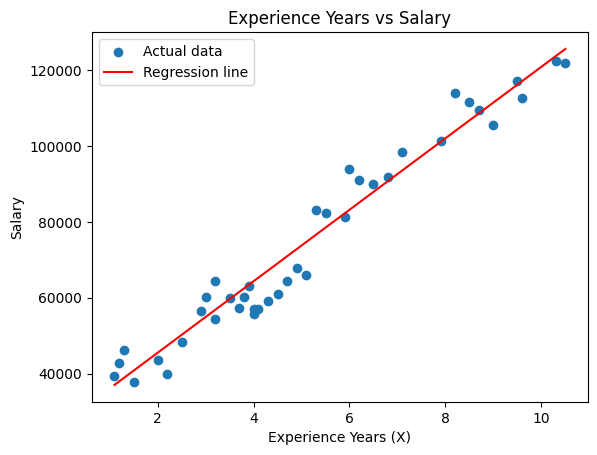

In [34]:
import matplotlib.pyplot as plt

y_pred_line = model.predict(X)

plt.scatter(X["Experience Years"], y, label="Actual data")
plt.plot(X["Experience Years"], y_pred_line, color="red", label="Regression line")
plt.xlabel("Experience Years (X)")
plt.ylabel("Salary")
plt.title("Experience Years vs Salary")
plt.legend()
plt.show()
